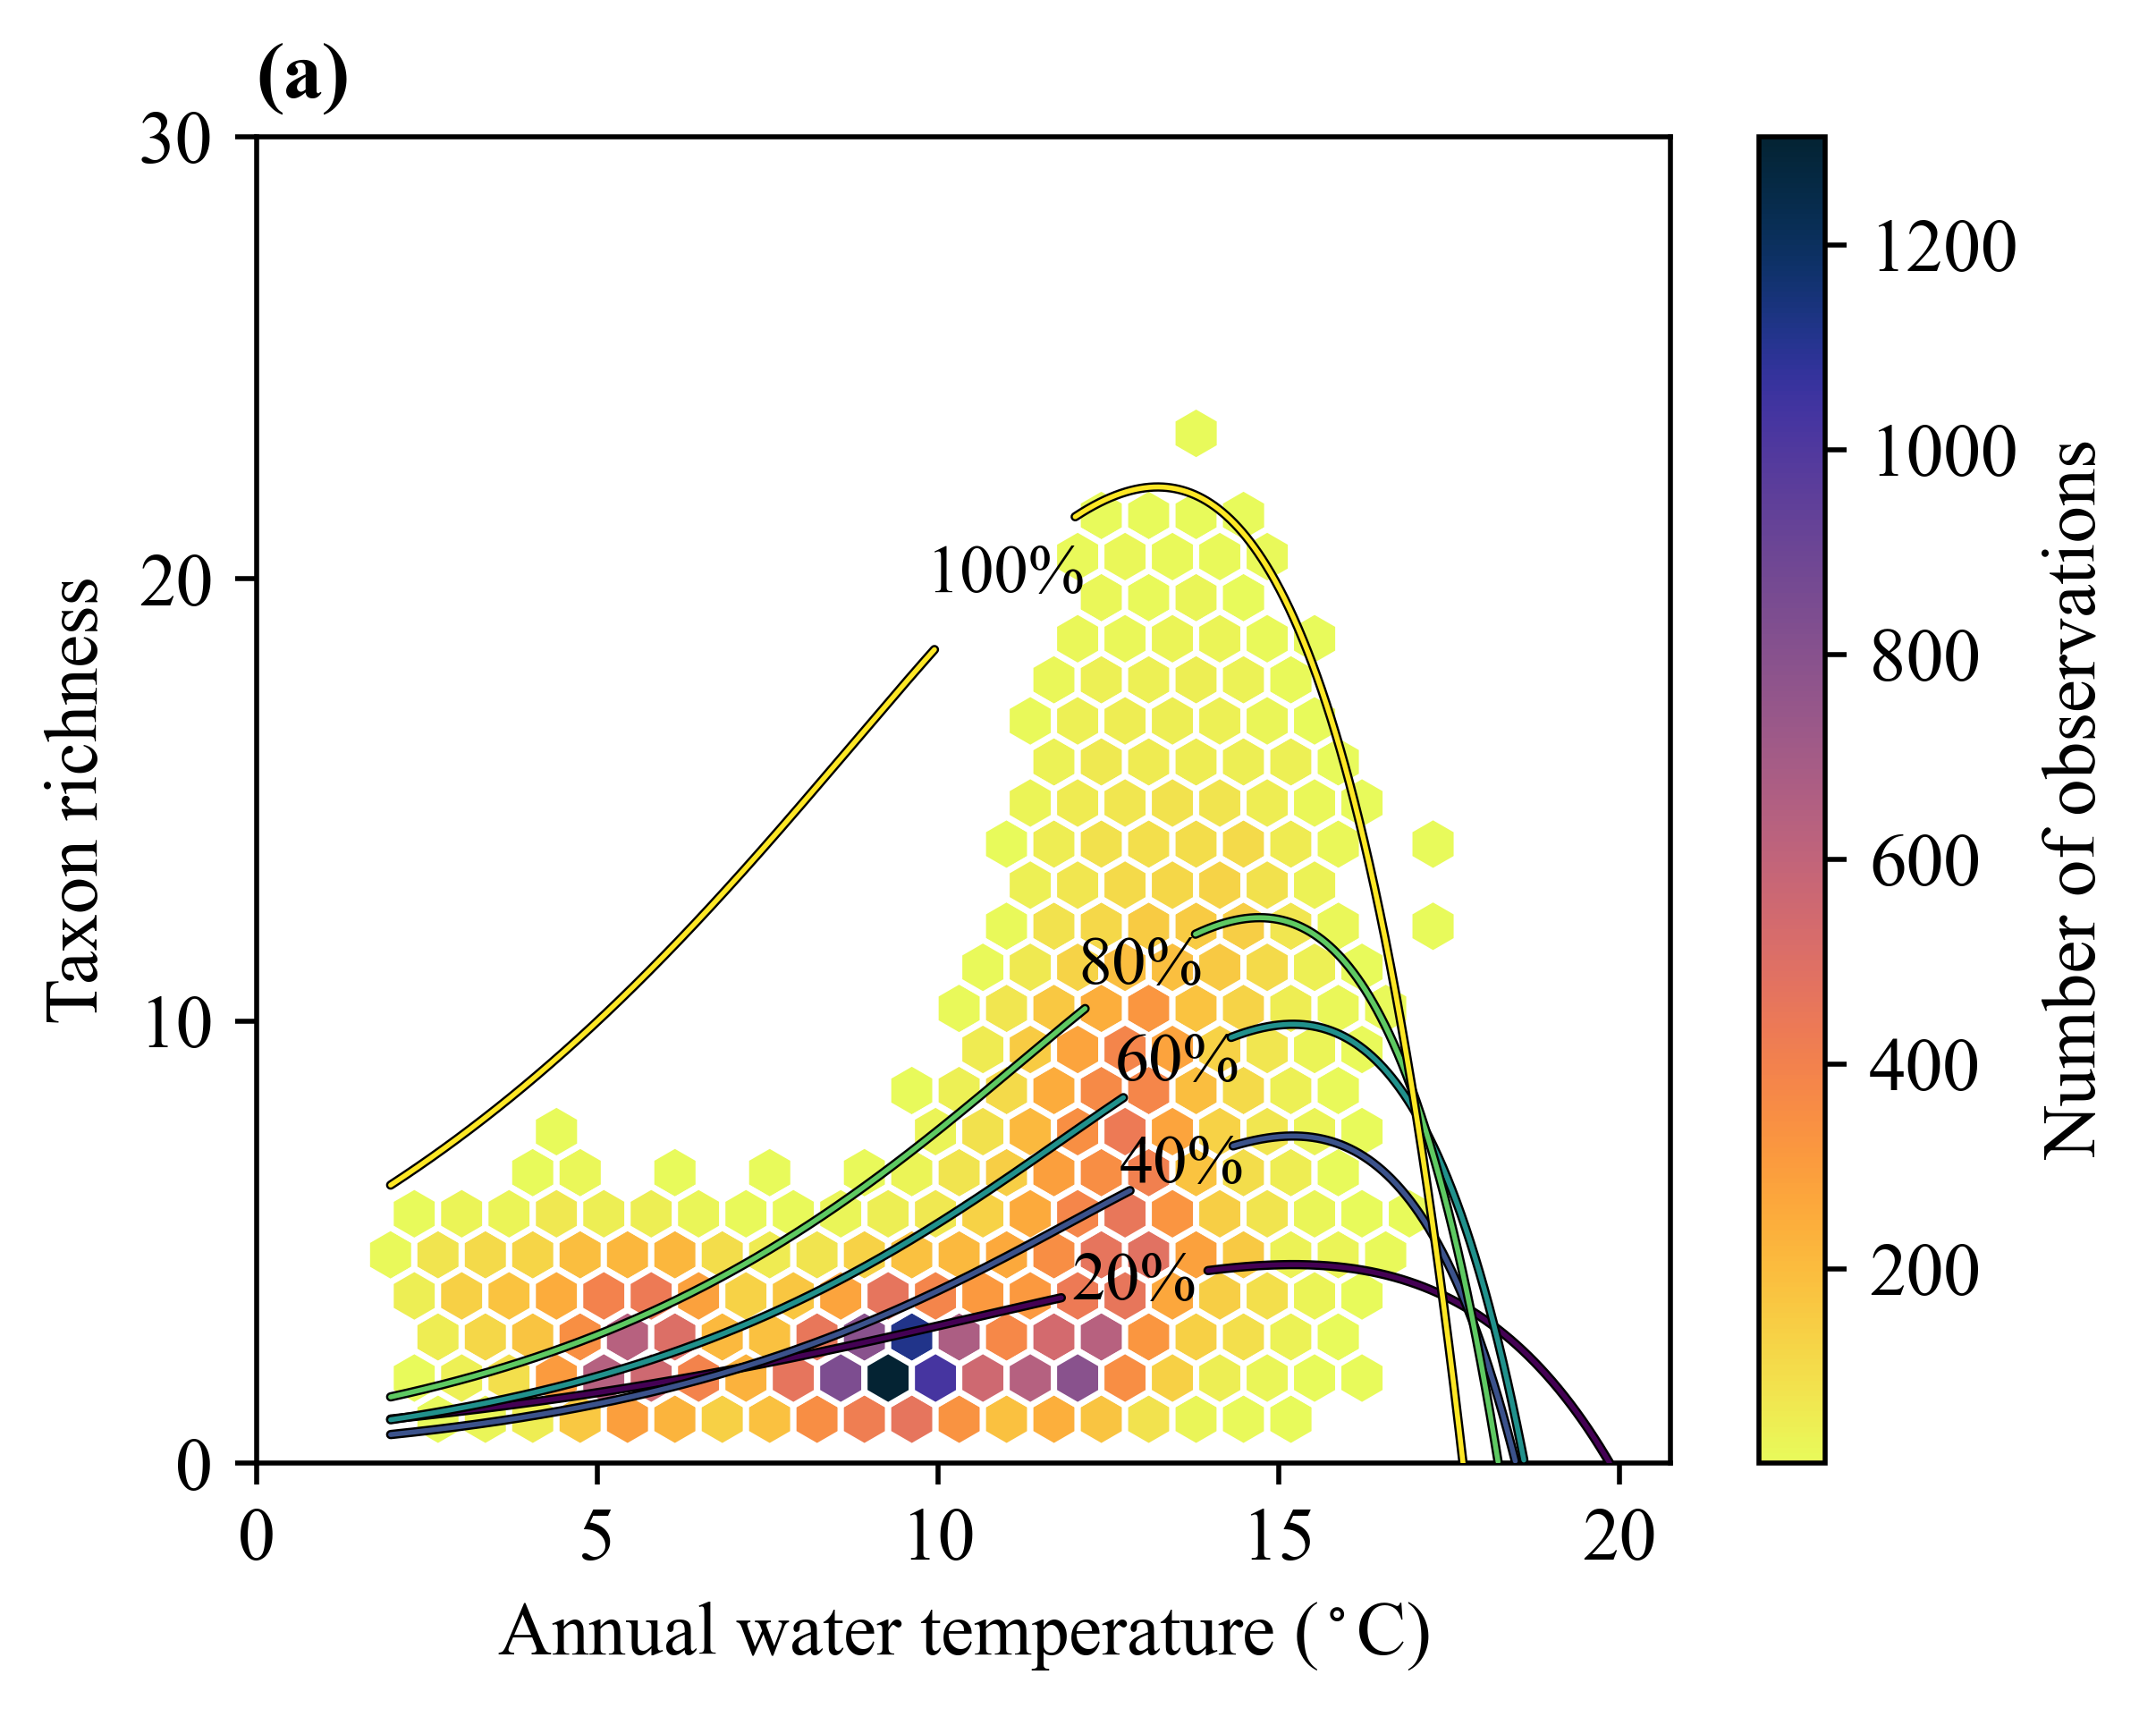

Saved: C:\Users\Lenovo\Desktop\5a.png


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib import rcParams
import cmaps

rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "mathtext.fontset": "stix"
})
file = r"D:\NC\Data\rivernet\inputdata\Richness.csv"
out_png = r"C:\Users\Lenovo\Desktop\5a.png"
df = pd.read_csv(file)
df["annual_temp"] = pd.to_numeric(df["annual_temp"], errors="coerce")
df["species_richness"] = pd.to_numeric(df["species_richness"], errors="coerce")
df = df.dropna(subset=["annual_temp", "species_richness"])

x = df["annual_temp"].values
y = df["species_richness"].values

# ======================
# UTPC function
# ======================
def utpc_fixed_Topt(T, Pmax, E, Topt):
    z = (T - Topt) / E
    return Pmax * np.exp(z) * (1 - z)
bin_width = 0.5
bins = np.arange(0, 20 + bin_width, bin_width)

q_list = [0.2, 0.4, 0.6, 0.8, 1.0]
MIN_N = 50

cmap_q = plt.cm.viridis
colors = {q: cmap_q(i / (len(q_list) - 1)) for i, q in enumerate(q_list)}

# ======================
fig, ax = plt.subplots(figsize=(5, 4), dpi=500)
hb = ax.hexbin(
    x, y,
    gridsize=25,
    mincnt=10,
    cmap=cmaps.cmocean_thermal_r,
    edgecolors="white"
)
for i, q in enumerate(q_list):

    T_fit, Y_fit = [], []

    for b0, b1 in zip(bins[:-1], bins[1:]):
        mask = (x >= b0) & (x < b1)
        if mask.sum() < MIN_N:
            continue

        T_fit.append(np.median(x[mask]))
        if q < 1.0:
            Y_fit.append(np.quantile(y[mask], q))
        else:
            Y_fit.append(np.max(y[mask]))

    T_fit = np.array(T_fit)
    Y_fit = np.array(Y_fit)

    if len(T_fit) < 5:
        continue
    i_peak = np.argmax(Y_fit)
    Topt = T_fit[i_peak]
    P0 = Y_fit.max()
    E0 = max((T_fit.max() - T_fit.min()) / 3, 0.5)

    try:
        popt, _ = curve_fit(
            lambda T, Pmax, E: utpc_fixed_Topt(T, Pmax, E, Topt),
            T_fit,
            Y_fit,
            p0=[P0, E0],
            bounds=([0, 0.1], [y.max() * 2, 20]),
            maxfev=50000
        )
    except RuntimeError:
        continue

    Pmax, E = popt

    T_line = np.linspace(
        max(0, x.min()),
        min(25, x.max() + 2),
        2000
    )
    Y_line = utpc_fixed_Topt(T_line, Pmax, E, Topt)

    valid = Y_line >= 0
    T_line = T_line[valid]
    Y_line = Y_line[valid]
    T_label = Topt - 0.5 * E
    gap = 0.23 * E

    mask_left  = T_line < (T_label - gap)
    mask_right = T_line > (T_label + gap)
    ax.plot(
        T_line[mask_left], Y_line[mask_left],
        color="black", lw=1.5,
        zorder=8 + i, solid_capstyle="round"
    )
    ax.plot(
        T_line[mask_left], Y_line[mask_left],
        color=colors[q], lw=0.8,
        zorder=9 + i, solid_capstyle="round"
    )
    ax.plot(
        T_line[mask_right], Y_line[mask_right],
        color="black", lw=1.5,
        zorder=8 + i, solid_capstyle="round"
    )
    ax.plot(
        T_line[mask_right], Y_line[mask_right],
        color=colors[q], lw=0.8,
        zorder=9 + i, solid_capstyle="round"
    )
    y_label = utpc_fixed_Topt(T_label, Pmax, E, Topt)

    label_text = f"{int(q*100)}%"


    ax.text(
        T_label,
        y_label,
        label_text,
        color='black',
        fontsize=11,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="none",
            edgecolor="none",
            alpha=1
        ),
        zorder=20
    )
ax.set_xlabel(r"Annual water temperature ($^\circ$C)")
ax.set_ylabel("Taxon richness")
ax.set_ylim(0, 30)
ax.set_yticks([0, 10, 20, 30])
ax.set_xticks([0, 5, 10, 15, 20])

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of observations")
ax.set_title("(a)", loc="left", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(out_png, dpi=500, bbox_inches="tight")
plt.show()
print("Saved:", out_png)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_424496\2491448489.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


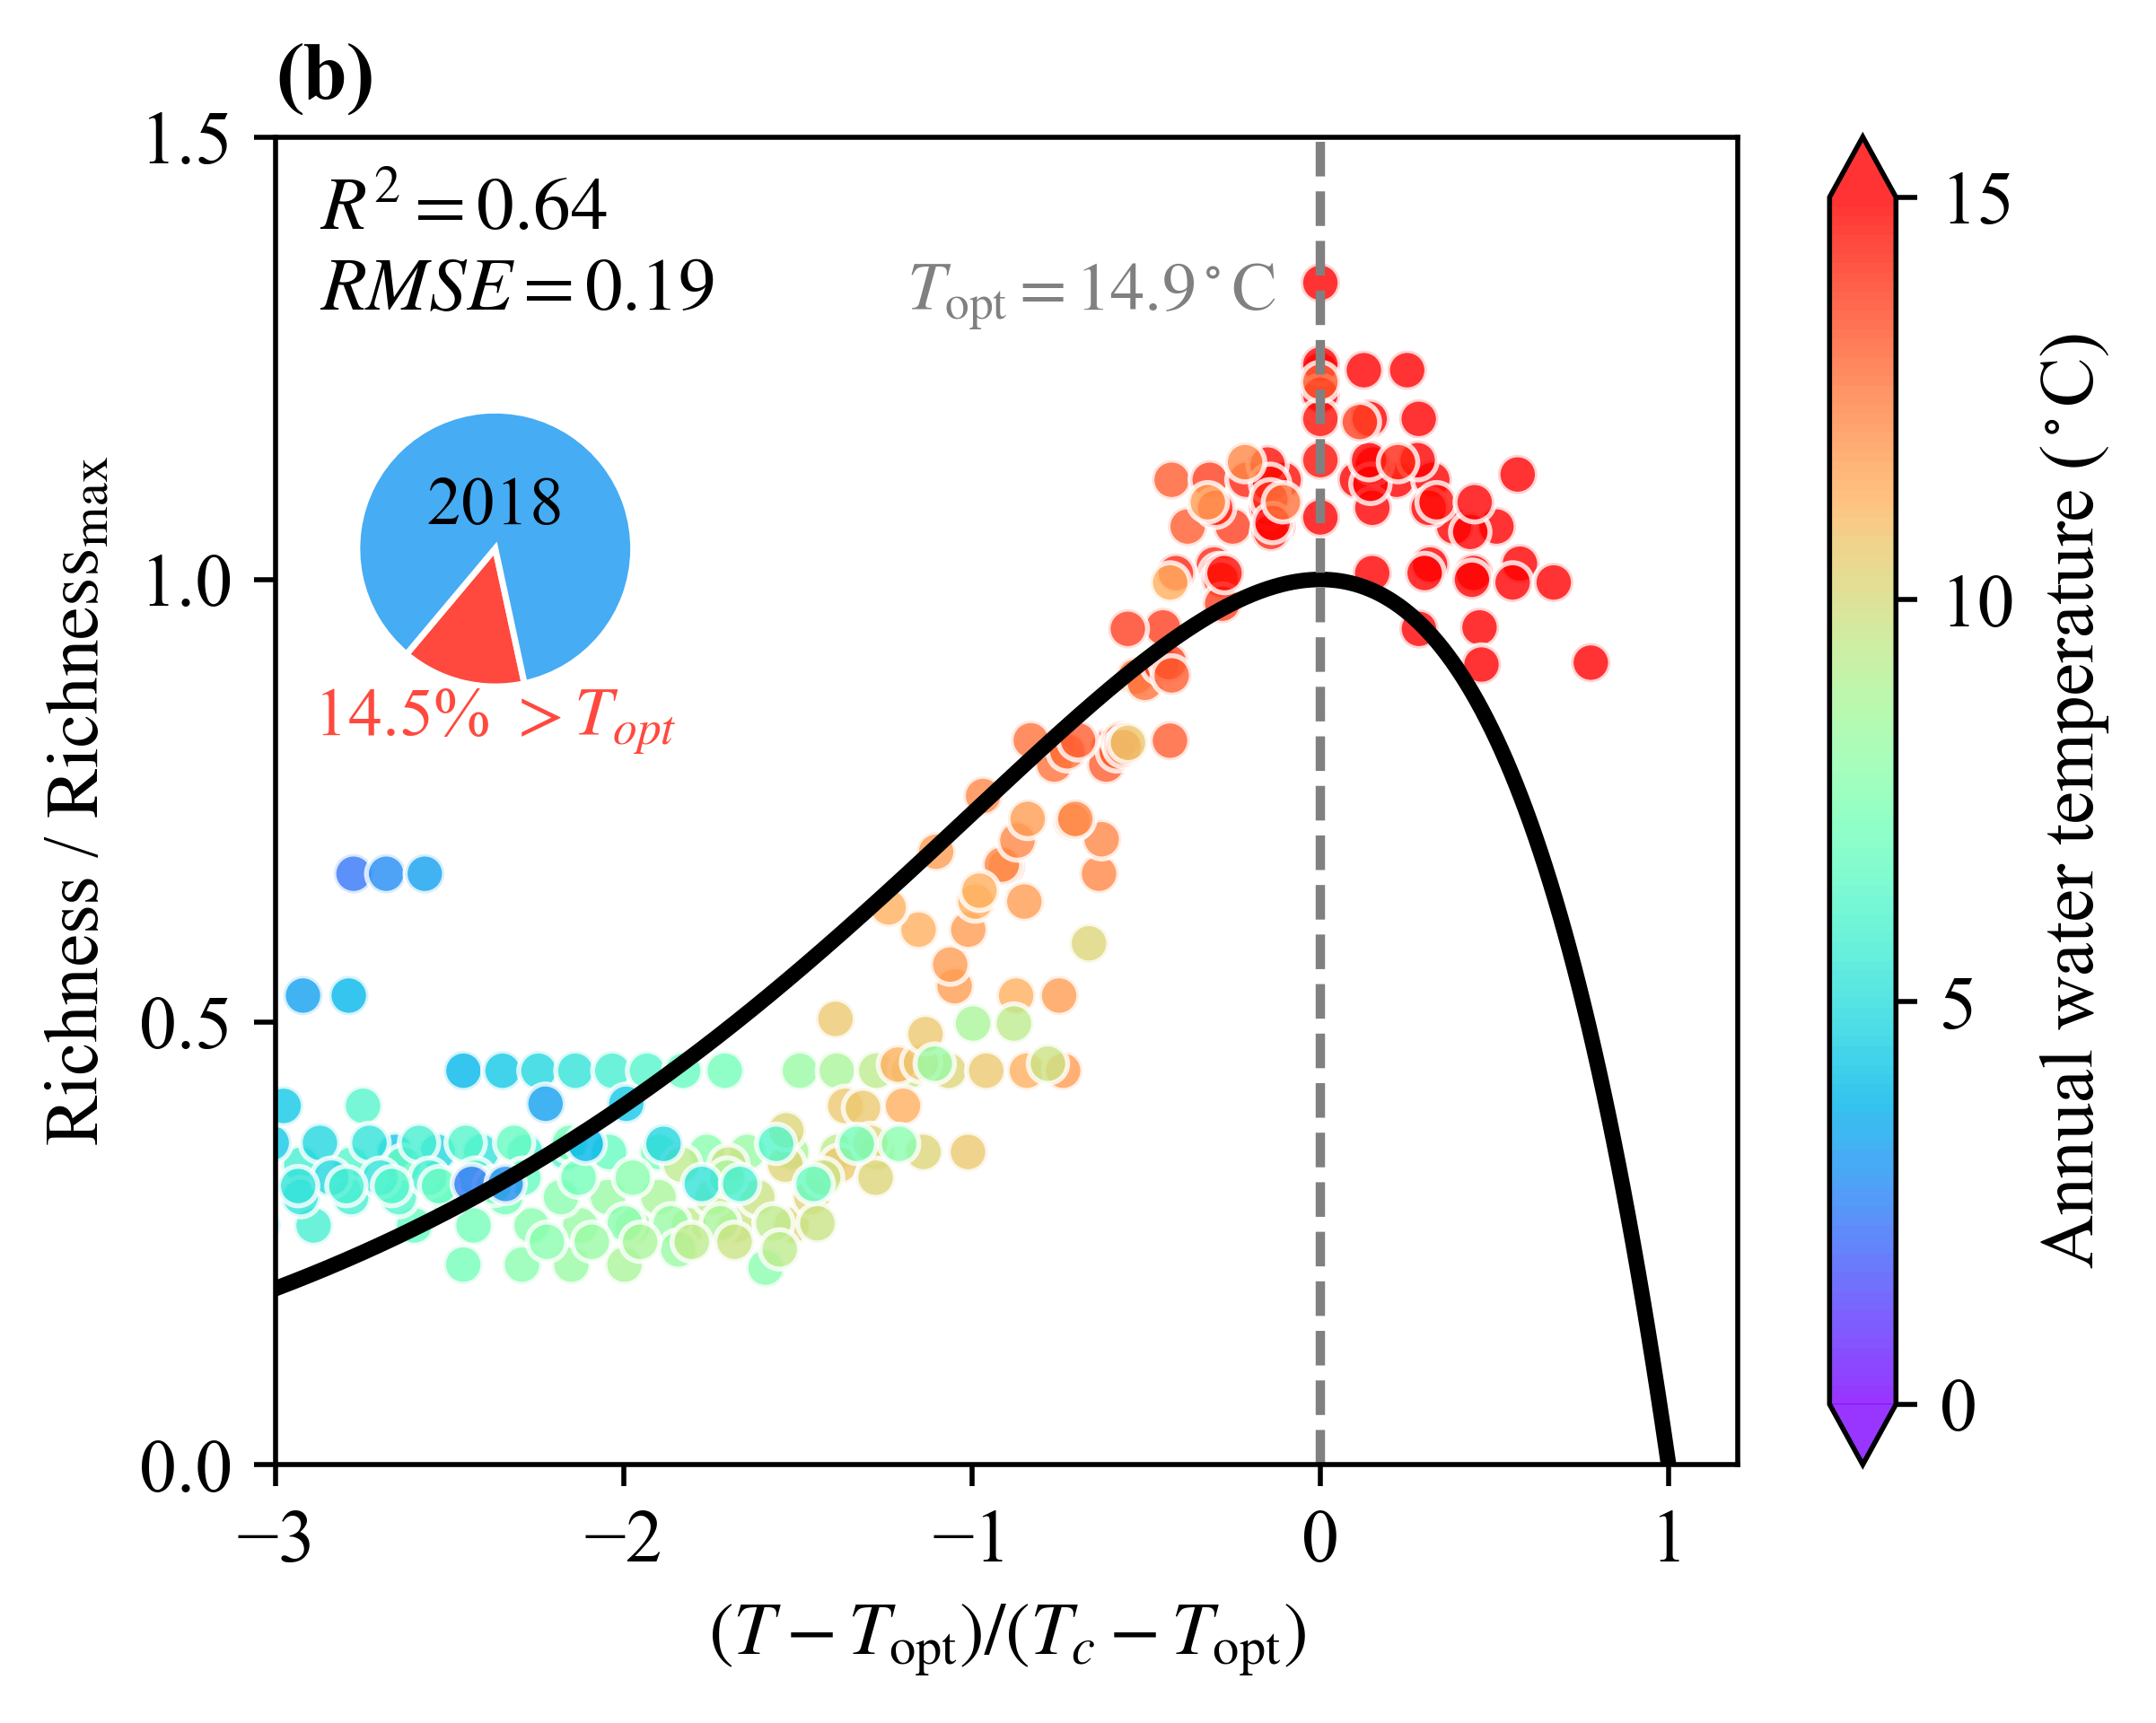

Saved: C:\Users\Lenovo\Desktop\5b.png


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib import rcParams
import cmaps

rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "mathtext.fontset": "stix"
})
file = r"D:\NC\Data\rivernet\inputdata\Richness.csv"
out_png = r"C:\Users\Lenovo\Desktop\5b.png"

df_temp = pd.read_parquet(
    r"D:\NC\Data\rivernet\inputdata\seg_annual_temperature_Q.parquet"
)
df_temp["year"] = pd.to_numeric(df_temp["year"], errors="coerce")
df_temp["temp_c_pred"] = pd.to_numeric(df_temp["temp_c_pred"], errors="coerce")
df_temp = df_temp.dropna(subset=["year", "temp_c_pred"])
df = pd.read_csv(file)

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["annual_temp"] = pd.to_numeric(df["annual_temp"], errors="coerce")
df["species_richness"] = pd.to_numeric(df["species_richness"], errors="coerce")

df = df.dropna(subset=["year", "annual_temp", "species_richness"])

x = df["annual_temp"].values
y = df["species_richness"].values
def utpc_fixed_Topt(T, Pmax, E, Topt):
    z = (T - Topt) / E
    return Pmax * np.exp(z) * (1 - z)

def utpc_collapse(xstar):
    return np.exp(xstar) * (1 - xstar)

bin_width = 0.5
bins = np.arange(0, 20 + bin_width, bin_width)

q_list = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
MIN_N = 50
collapse_records = []
qt_params = {}

for q in q_list:

    T_fit, Y_fit = [], []

    for b0, b1 in zip(bins[:-1], bins[1:]):
        mask = (x >= b0) & (x < b1)
        if mask.sum() < MIN_N:
            continue

        T_fit.append(np.median(x[mask]))
        Y_fit.append(np.quantile(y[mask], q))

    T_fit = np.array(T_fit)
    Y_fit = np.array(Y_fit)

    if len(T_fit) < 6:
        continue

    Topt = T_fit[np.argmax(Y_fit)]
    P0 = Y_fit.max()
    E0 = max((T_fit.max() - T_fit.min()) / 3, 0.5)

    try:
        popt, _ = curve_fit(
            lambda T, Pmax, E: utpc_fixed_Topt(T, Pmax, E, Topt),
            T_fit, Y_fit,
            p0=[P0, E0],
            bounds=([0, 0.1], [y.max() * 2, 20]),
            maxfev=50000
        )
    except RuntimeError:
        continue

    Pmax, E = popt
    Tc = Topt + E

    qt_params[q] = {"Topt": Topt, "Tc": Tc}

    x_star = (T_fit - Topt) / (Tc - Topt)
    y_star = Y_fit / Pmax
    for i, (xs, ys) in enumerate(zip(x_star, y_star)):
        if ys >= 0:
            collapse_records.append([xs, ys, T_fit[i]])

df_col = pd.DataFrame(
    collapse_records,
    columns=["x_star", "y_star", "T"]
)

x_all = df_col["x_star"].values
y_all = df_col["y_star"].values
y_pred = utpc_collapse(x_all)
valid = (~np.isnan(y_all)) & (~np.isnan(y_pred))

x_all = x_all[valid]
y_all = y_all[valid]
y_pred = y_pred[valid]

r2 = 1 - np.sum((y_all - y_pred) ** 2) / np.sum((y_all - y_all.mean()) ** 2)
rmse = np.sqrt(np.mean((y_all - y_pred) ** 2))
x_theory = np.linspace(-3, 1.2, 600)
y_theory = utpc_collapse(x_theory)
y_theory[y_theory < 0] = np.nan
Topt_all = [v["Topt"] for v in qt_params.values()]
Topt_mean = np.mean(Topt_all)
fig, ax = plt.subplots(figsize=(5, 4), dpi=500)

sc = ax.scatter(
    x_all,
    y_all,
    c=df_col["T"].values,
    # cmap="viridis",
    cmap = cmaps.MPL_rainbow,
    s=40,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.8,
    zorder=1
)

ax.plot(x_theory, y_theory, color="black", lw=2.5, zorder=2)
# ax.plot(x_theory, y_theory, color="white", lw=1.0, zorder=3)

ax.axvline(x=0, color="gray", linestyle="--", lw=1.5)
x_shift = -0.12 * (ax.get_xlim()[1] - ax.get_xlim()[0])
ax.text(
    x_shift,
    ax.get_ylim()[1] * 0.97,
    rf"$T_{{\mathrm{{opt}}}} = {Topt_mean:.1f}^\circ$C",
    ha="center",
    va="top",
    fontsize=11,
    color="gray"
)



ax.set_xlabel(r"$(T - T_{\mathrm{opt}})/(T_c - T_{\mathrm{opt}})$")
ax.set_ylabel(r"Richness / $\mathrm{Richness}_{\max}$")
ax.set_xlim(-3, 1.2)
ax.set_ylim(0, 1.5)
ax.set_yticks([0, 0.5, 1, 1.5])

ax.text(
    0.03, 0.97,
    rf"$R^2 = {r2:.2f}$" + "\n" + rf"$RMSE = {rmse:.2f}$",
    transform=ax.transAxes,
    ha="left",
    va="top"
)

sc.set_clim(0, 15)  
cb = plt.colorbar(
    sc,
    ax=ax,
    extend="both"
)
cb.set_label(r"Annual water temperature ($^\circ$C)")
cb.set_ticks([0, 5, 10, 15])
ax.set_title("(b)", loc="left", fontweight="bold", fontsize=13)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
percent_above = 14.5        
percent_below = 100 - percent_above

sizes = [percent_above, percent_below]
colors = ["#ff493e", "#46acf4"]   

ax_pie = inset_axes(
    ax,
    width="26%",
    height="26%",
    loc="upper left",
    bbox_to_anchor=(0.02, -0.18, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

ax_pie.pie(
    sizes,
    startangle=230,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1)
)
ax_pie.set_aspect("equal")
ax_pie.axis("off")
ax_pie.text(
    0.5, 0,
    rf"{percent_above:.1f}% $> T_{{opt}}$",
    color="#ff493e",
    fontsize=11,
    # fontweight="bold",
    ha="center",
    va="center",
    transform=ax_pie.transAxes
)

ax_pie.text(
    0.5, 0.62,
    "2018",
    color="black",
    fontsize=11,
    ha="center",
    va="center",
    transform=ax_pie.transAxes
)
plt.tight_layout()
plt.savefig(out_png, dpi=500, bbox_inches="tight")
plt.show()

print("Saved:", out_png)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_424496\4018514062.py:17: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


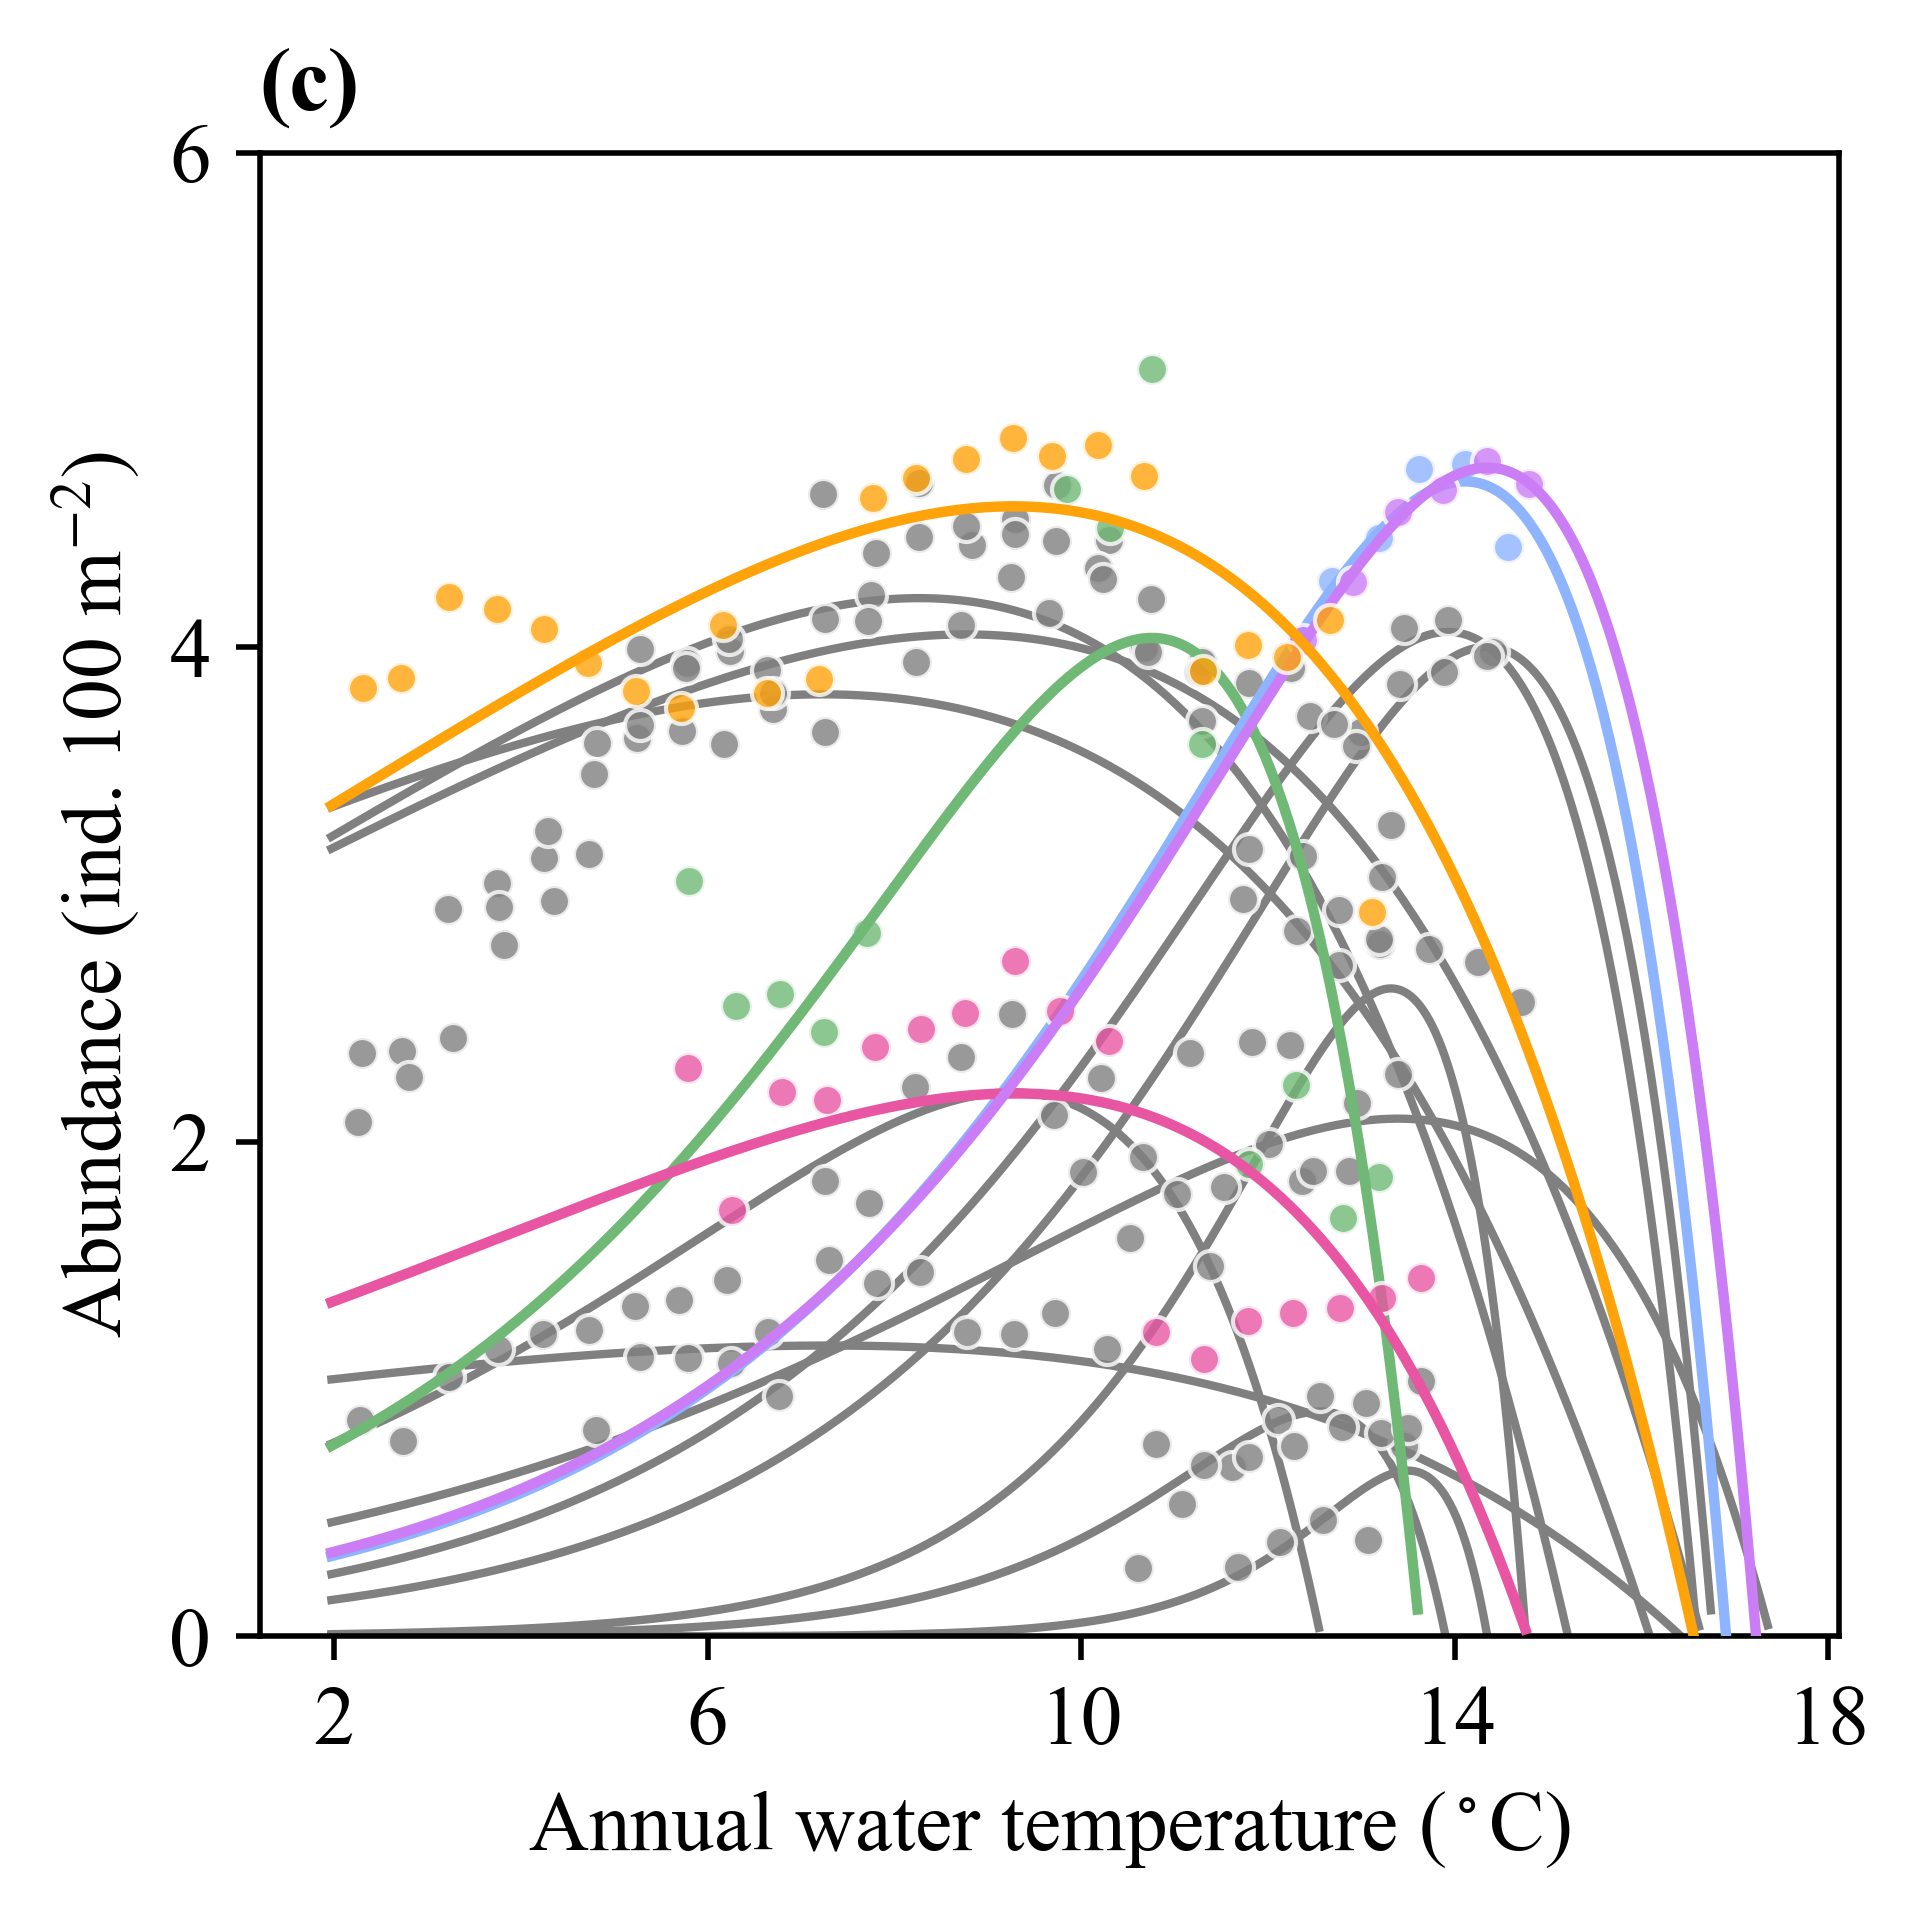

After density filter (MIN_N=50): 24
Successful TPC fits (ALL): 24
Used for plotting (R² ≥ 0.3): 16
Saved CSV: C:\Users\Lenovo\Desktop\TableS7.csv
Saved figure: C:\Users\Lenovo\Desktop\5c.png


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib import rcParams

rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "mathtext.fontset": "stix"
})

file = r"D:\NC\Data\rivernet\inputdata\Abundance.csv"
out_png = r"C:\Users\Lenovo\Desktop\5c.png"
out_csv = r"C:\Users\Lenovo\outputdata\TableS5.csv"
df = pd.read_csv(file)

df["annual_temp"] = pd.to_numeric(df["annual_temp"], errors="coerce")
df["Abundance"]   = pd.to_numeric(df["Abundance"], errors="coerce")

df = df[
    (df["UnitAbundance"] == "Ind.100m2") &
    (~df["annual_temp"].isna()) &
    (~df["Abundance"].isna()) &
    (df["Abundance"] >= 0)
].copy()

df["log_abun"] = np.log1p(df["Abundance"])
focus_species = [
    "Salmo salar",
    "Perca fluviatilis",
    "Barbatula barbatula",
    "Phoxinus bigerri",
    "Parachondrostoma miegii"
]

focus_colors = {
    "Salmo salar": "#ffa30a",         
    "Perca fluviatilis": "#e856a3",    
    "Barbatula barbatula": "#70b875",  
    "Phoxinus bigerri": "#cb7df5",     
    "Parachondrostoma miegii": "#8eb3ff"  
}

BG_COLOR = "gray"
def utpc_fixed_Topt(T, Pmax, E, Topt):
    z = (T - Topt) / E
    return Pmax * np.exp(z) * (1 - z)

MIN_N     = 50
BIN_WIDTH = 0.5
MIN_BINS  = 5
R2_TH     = 0.3

T_global = np.linspace(
    df["annual_temp"].min(),
    df["annual_temp"].max(),
    500
)

species_pass_density = []
species_pass_plot    = []
species_stats_all    = []
fig, ax = plt.subplots(figsize=(4, 4), dpi=500)

for sp, sub in df.groupby("Species"):

    is_focus = sp in focus_species

    x = sub["annual_temp"].values
    y = sub["log_abun"].values

    bins = np.arange(x.min(), x.max() + BIN_WIDTH, BIN_WIDTH)

    T_fit, Y_fit = [], []

    for b0, b1 in zip(bins[:-1], bins[1:]):
        mask = (x >= b0) & (x < b1)
        if mask.sum() < MIN_N:
            continue
        T_fit.append(np.median(x[mask]))
        Y_fit.append(np.quantile(y[mask], 0.9))

    T_fit = np.array(T_fit)
    Y_fit = np.array(Y_fit)

    if len(T_fit) < MIN_BINS:
        continue

    species_pass_density.append(sp)

    i_peak = np.argmax(Y_fit)
    Topt0  = T_fit[i_peak]
    P0     = Y_fit.max()
    E0     = max((T_fit.max() - T_fit.min()) / 3, 1.0)

    try:
        popt, _ = curve_fit(
            lambda T, Pmax, E: utpc_fixed_Topt(T, Pmax, E, Topt0),
            T_fit, Y_fit,
            p0=[P0, E0],
            bounds=([0, 0.5], [np.inf, 20]),
            maxfev=30000
        )
    except RuntimeError:
        continue

    Pmax, E = popt
    Y_pred = utpc_fixed_Topt(T_fit, Pmax, E, Topt0)

    ss_res = np.sum((Y_fit - Y_pred) ** 2)
    ss_tot = np.sum((Y_fit - Y_fit.mean()) ** 2)
    if ss_tot <= 0:
        continue

    r2 = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((Y_fit - Y_pred) ** 2))
    species_stats_all.append([sp, r2, rmse])

    if r2 < R2_TH:
        continue

    species_pass_plot.append(sp)
    point_color = focus_colors[sp] if is_focus else BG_COLOR
    ax.scatter(
        T_fit, Y_fit,
        s=20,
        facecolor=point_color,
        edgecolor="white",
        linewidth=0.6,
        alpha=0.8 if is_focus else 0.8,
        zorder=6 if is_focus else 3
    )

    Y_line = utpc_fixed_Topt(T_global, Pmax, E, Topt0)
    valid = Y_line > 0
    last_idx = np.where(valid)[0][-1]

    if is_focus:
        ax.plot(
            T_global[:last_idx + 1],
            Y_line[:last_idx + 1],
            color=focus_colors[sp],
            lw=1.5,
            zorder=6
        )
    else:
        ax.plot(
            T_global[:last_idx + 1],
            Y_line[:last_idx + 1],
            color=BG_COLOR,
            lw=1.2,
            alpha=1,
            zorder=2
        )

ax.set_xlabel(r"Annual water temperature ($^\circ$C)")
ax.set_ylabel(r"Abundance (ind. 100 m$^{-2}$)")
ax.set_ylim(0, 6)
ax.set_yticks([0, 2, 4, 6])
ax.set_xticks([2, 6, 10, 14, 18])
ax.set_title("(c)", loc="left", fontweight="bold", fontsize=13)

plt.tight_layout()
plt.savefig(out_png, dpi=500, bbox_inches="tight")
plt.show()

print("======================================")
print(f"After density filter (MIN_N=50): {len(set(species_pass_density))}")
print(f"Successful TPC fits (ALL): {len(species_stats_all)}")
print(f"Used for plotting (R² ≥ {R2_TH}): {len(set(species_pass_plot))}")
print("======================================")

df_stats = pd.DataFrame(
    species_stats_all,
    columns=["Species", "R2", "RMSE"]
).sort_values("R2", ascending=False)

df_stats.to_csv(out_csv, index=False)

print("Saved CSV:", out_csv)
print("Saved figure:", out_png)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_424496\540689468.py:18: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_424496\540689468.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


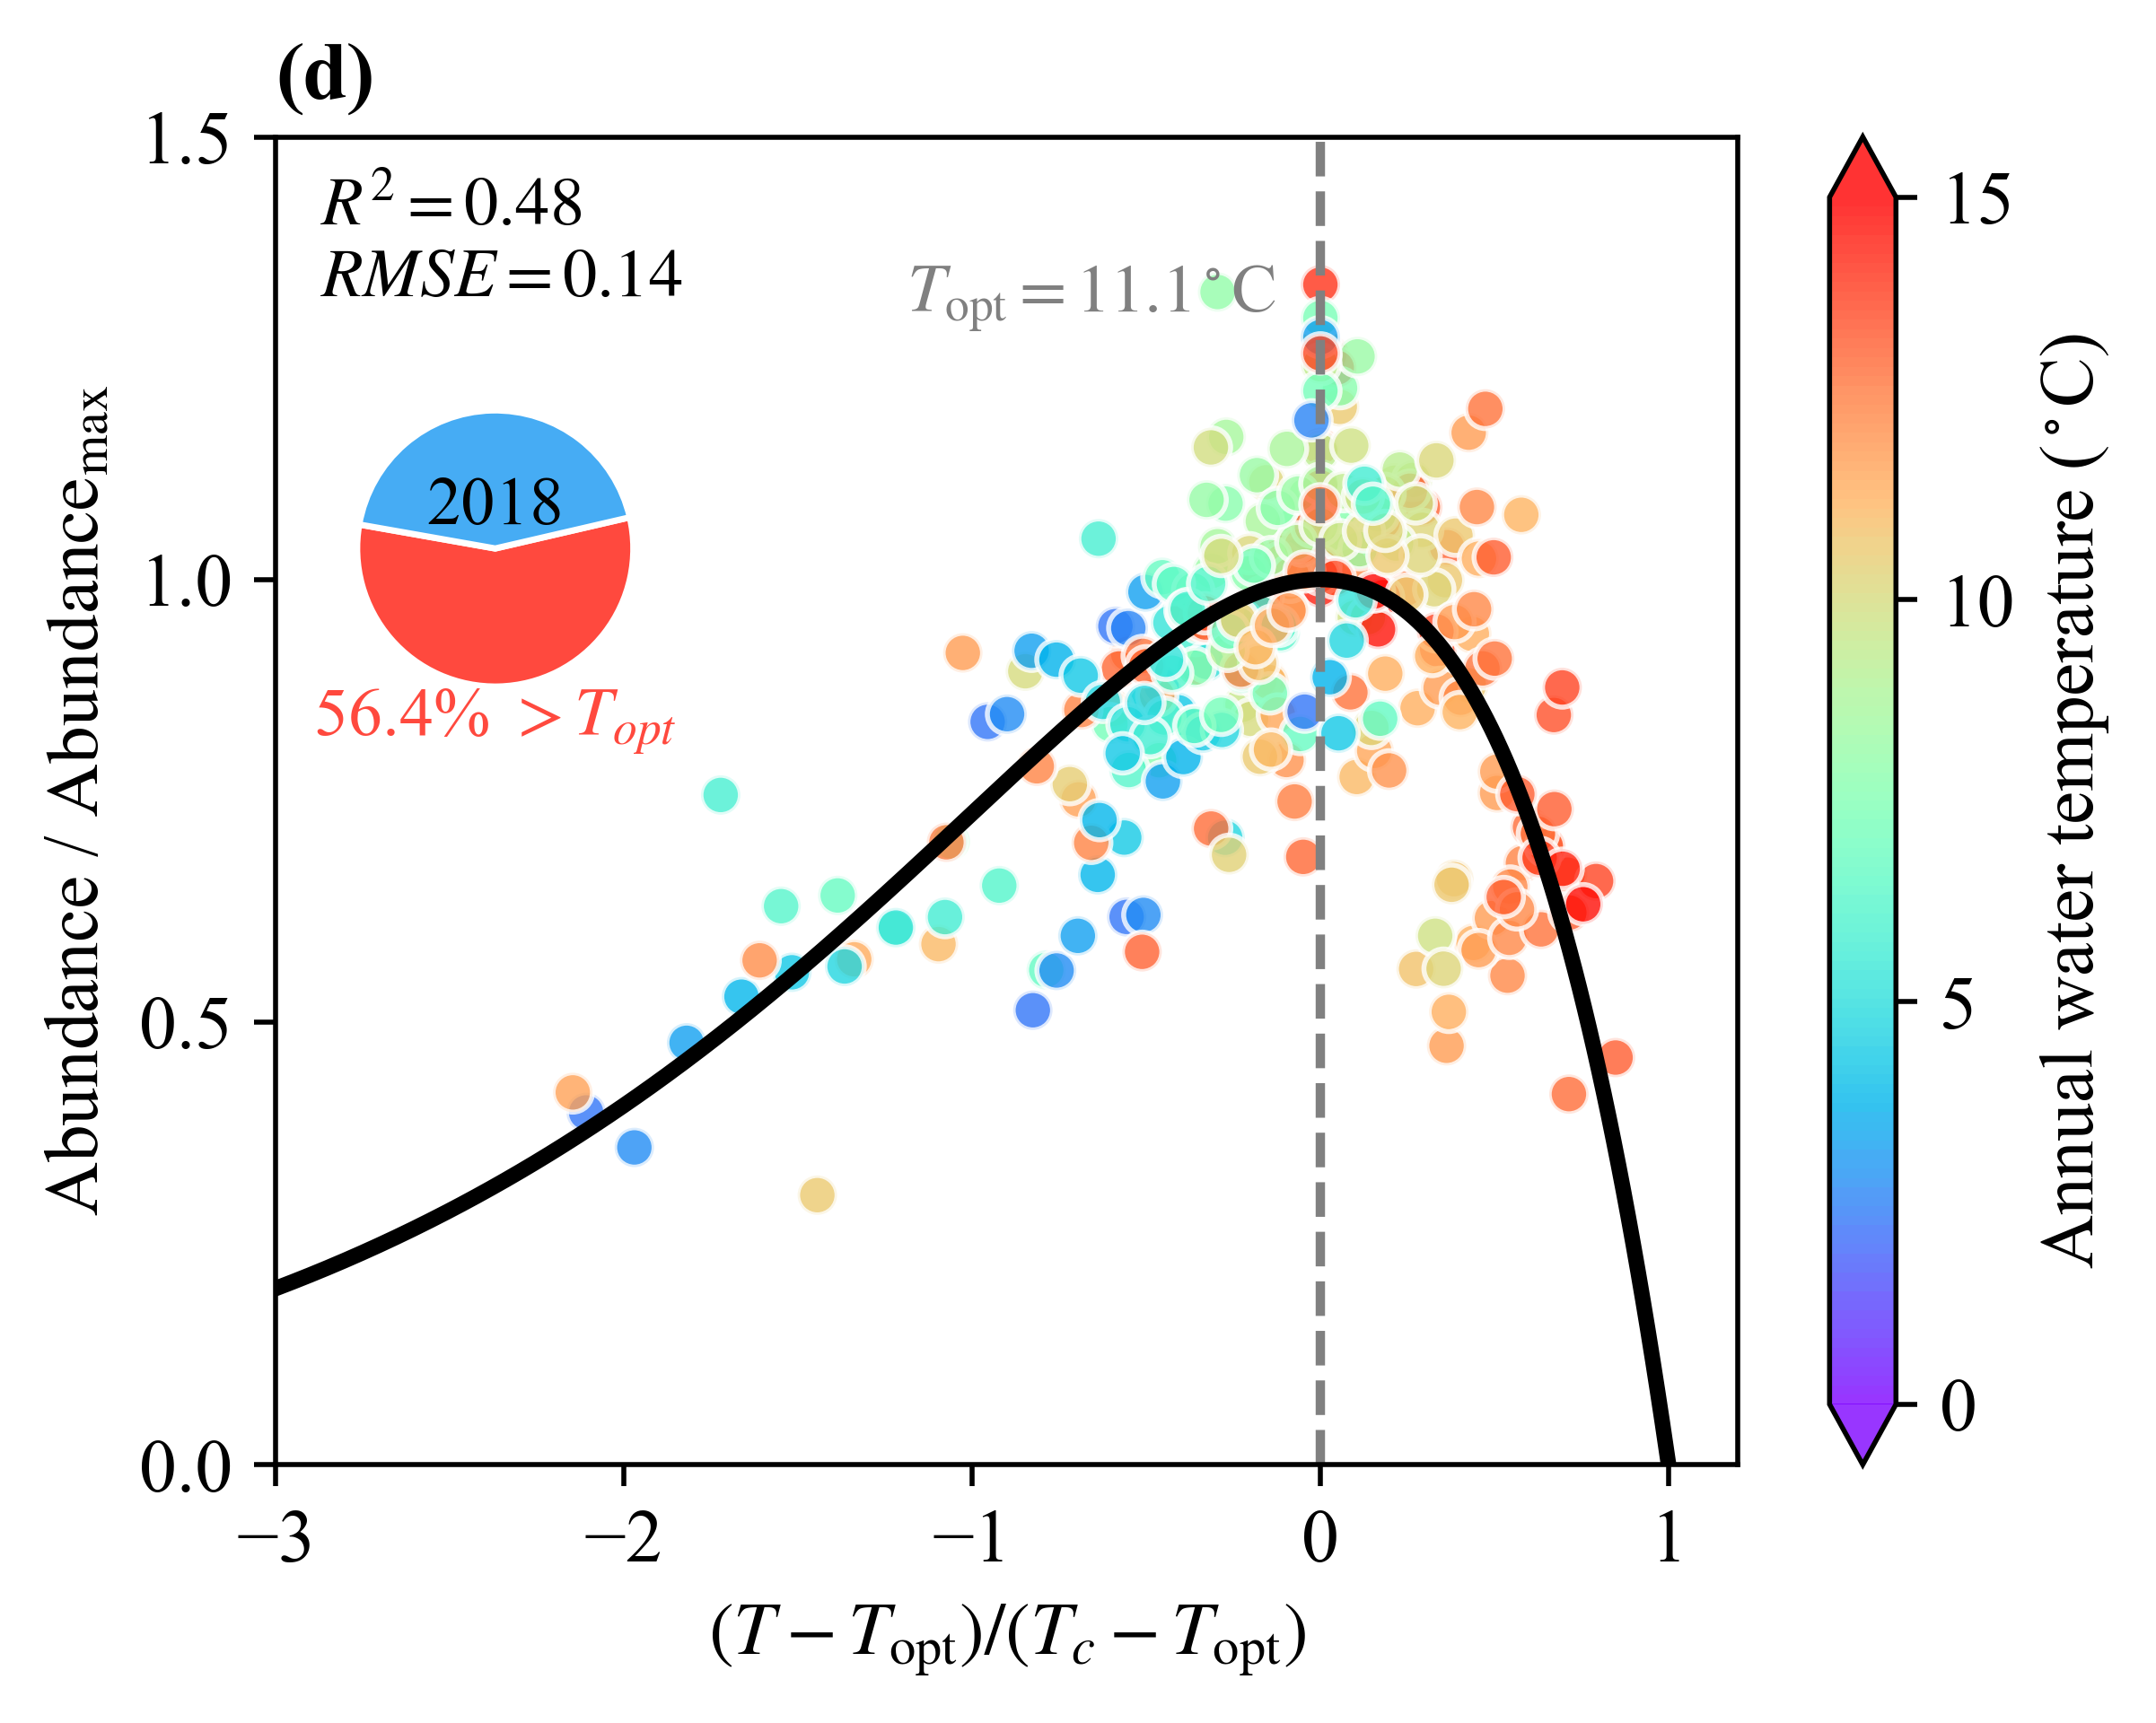

Saved: C:\Users\Lenovo\Desktop\5d.png
Collapse R2 = 0.482, RMSE = 0.141


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib import rcParams
import cmaps

rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "mathtext.fontset": "stix"
})

file = r"D:\NC\Data\rivernet\inputdata\Abundance.csv"
out_png = r"C:\Users\Lenovo\Desktop\5d.png"

df = pd.read_csv(file)

df["annual_temp"] = pd.to_numeric(df["annual_temp"], errors="coerce")
df["Abundance"]   = pd.to_numeric(df["Abundance"], errors="coerce")

df = df[
    (df["UnitAbundance"] == "Ind.100m2") &
    (~df["annual_temp"].isna()) &
    (~df["Abundance"].isna()) &
    (df["Abundance"] >= 0)
].copy()

df["log_abun"] = np.log1p(df["Abundance"])
def utpc_fixed_Topt(T, Pmax, E, Topt):
    z = (T - Topt) / E
    return Pmax * np.exp(z) * (1 - z)

def utpc_collapse(x):
    return np.exp(x) * (1 - x)

MIN_N     = 50
BIN_WIDTH = 0.5
MIN_BINS  = 5


collapse_records = []
Topt_list = []

for sp, sub in df.groupby("Species"):

    x = sub["annual_temp"].values
    y = sub["log_abun"].values

    bins = np.arange(x.min(), x.max() + BIN_WIDTH, BIN_WIDTH)

    T_fit, Y_fit = [], []

    for b0, b1 in zip(bins[:-1], bins[1:]):
        mask = (x >= b0) & (x < b1)
        if mask.sum() < MIN_N:
            continue
        T_fit.append(np.median(x[mask]))
        Y_fit.append(np.quantile(y[mask], 0.9))

    T_fit = np.array(T_fit)
    Y_fit = np.array(Y_fit)

    if len(T_fit) < MIN_BINS:
        continue

    i_peak = np.argmax(Y_fit)
    Topt   = T_fit[i_peak]
    P0     = Y_fit.max()
    E0     = max((T_fit.max() - T_fit.min()) / 3, 1.0)

    try:
        popt, _ = curve_fit(
            lambda T, Pmax, E: utpc_fixed_Topt(T, Pmax, E, Topt),
            T_fit, Y_fit,
            p0=[P0, E0],
            bounds=([0, 0.5], [np.inf, 20]),
            maxfev=30000
        )
    except RuntimeError:
        continue

    Pmax, E = popt
    Tc = Topt + E
    Y_pred = utpc_fixed_Topt(T_fit, Pmax, E, Topt)
    ss_res = np.sum((Y_fit - Y_pred) ** 2)
    ss_tot = np.sum((Y_fit - Y_fit.mean()) ** 2)
    if ss_tot <= 0:
        continue
    r2_sp = 1 - ss_res / ss_tot

    Topt_list.append(Topt)
    x_star = (T_fit - Topt) / (Tc - Topt)
    y_star = Y_fit / Pmax

    for xs, ys, Tval in zip(x_star, y_star, T_fit):
        if ys > 0:
            collapse_records.append([xs, ys, Tval])
df_col = pd.DataFrame(
    collapse_records,
    columns=["x_star", "y_star", "T"]
)

x_all = df_col["x_star"].values
y_all = df_col["y_star"].values
y_pred_all = utpc_collapse(x_all)

valid = (~np.isnan(y_all)) & (~np.isnan(y_pred_all))
x_all = x_all[valid]
y_all = y_all[valid]
y_pred_all = y_pred_all[valid]

r2 = 1 - np.sum((y_all - y_pred_all) ** 2) / np.sum((y_all - y_all.mean()) ** 2)
rmse = np.sqrt(np.mean((y_all - y_pred_all) ** 2))
x_theory = np.linspace(-3, 1.2, 600)
y_theory = utpc_collapse(x_theory)
y_theory[y_theory < 0] = np.nan

Topt_mean = np.mean(Topt_list)
fig, ax = plt.subplots(figsize=(5, 4), dpi=500)

sc = ax.scatter(
    x_all,
    y_all,
    c=df_col["T"].values,
    cmap=cmaps.MPL_rainbow,
    s=40,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.8,
    zorder=1
)

# ax.plot(x_theory, y_theory, color="black", lw=3.0, zorder=2)
ax.plot(x_theory, y_theory, color="black", lw=2.5, zorder=3)
ax.axvline(x=0, color="gray", linestyle="--", lw=1.5)
x_shift = -0.15 * (ax.get_xlim()[1] - ax.get_xlim()[0])
ax.text(
    x_shift,
    ax.get_ylim()[1] * 0.97,
    rf"$T_{{\mathrm{{opt}}}} = {Topt_mean:.1f}^\circ$C",
    ha="center",
    va="top",
    fontsize=11,
    color="gray"
)
ax.text(
    0.03, 0.97,
    rf"$R^2 = {r2:.2f}$" + "\n" + rf"$RMSE = {rmse:.2f}$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11
)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
percent_above = 56.4        
percent_below = 100 - percent_above

sizes = [percent_above, percent_below]
colors = ["#ff493e", "#46acf4"]   

ax_pie = inset_axes(
    ax,
    width="26%",
    height="26%",
    loc="upper left",
    bbox_to_anchor=(0.02, -0.18, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

ax_pie.pie(
    sizes,
    startangle=170,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1)
)
ax_pie.set_aspect("equal")
ax_pie.axis("off")
ax_pie.text(
    0.5, 0,
    rf"{percent_above:.1f}% $> T_{{opt}}$",
    color="#ff493e",
    fontsize=11,
    # fontweight="bold",
    ha="center",
    va="center",
    transform=ax_pie.transAxes
)

ax_pie.text(
    0.5, 0.62,
    "2018",
    color="black",
    fontsize=11,
    ha="center",
    va="center",
    transform=ax_pie.transAxes
)



ax.set_xlabel(r"$(T - T_{\mathrm{opt}})/(T_c - T_{\mathrm{opt}})$")
ax.set_ylabel(r"Abundance / $\mathrm{Abundance}_{\max}$")

ax.set_xlim(-3, 1.2)
ax.set_ylim(0, 1.5)
ax.set_yticks([0, 0.5, 1, 1.5])

sc.set_clim(0, 15) 

cb = plt.colorbar(
    sc,
    ax=ax,
    extend="both"
)

cb.set_label(r"Annual water temperature ($^\circ$C)")
cb.set_ticks([0, 5, 10, 15])
ax.set_title("(d)", loc="left", fontweight="bold", fontsize=13)

plt.tight_layout()
plt.savefig(out_png, dpi=500, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print(f"Collapse R2 = {r2:.3f}, RMSE = {rmse:.3f}")